In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
df = pd.read_csv("classroom air quality.csv")
df

,timestamp,school_period,student_count_estimated,co2_ppm,pm25_ugm3,temperature_c,humidity_pct,robot_x_pos,robot_y_pos,ventilation_decision,air_quality_label
0,12-11-2025 08:00,Morning Entry,11,442.1,5.16,21.0,45.0,2.0,4.0,IDLE,Good
1,12-11-2025 08:01,Morning Entry,6,444.6,5.08,21.0,44.8,2.2,4.0,IDLE,Good
2,12-11-2025 08:03,Morning Entry,11,466.9,5.93,21.0,44.7,2.7,3.8,IDLE,Good
3,12-11-2025 08:05,Morning Entry,6,483.6,5.49,21.0,44.6,2.7,3.8,IDLE,Good
4,12-11-2025 08:06,Morning Entry,16,520.6,6.25,21.0,44.7,3.2,3.9,IDLE,Good
...,...,...,...,...,...,...,...,...,...,...,...
495,12-11-2025 22:01,End of Day,4,501.6,6.26,20.2,41.8,0.0,0.0,IDLE,Good
496,12-11-2025 22:03,End of Day,1,474.9,6.66,20.2,41.6,0.2,0.0,IDLE,Good
497,12-11-2025 22:04,End of Day,0,454.7,6.26,20.2,41.5,0.5,0.1,IDLE,Good
498,12-11-2025 22:06,End of Day,6,471.8,6.13,20.2,41.5,0.7,0.0,IDLE,Good


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   timestamp                500 non-null    str    
 1   school_period            500 non-null    str    
 2   student_count_estimated  500 non-null    int64  
 3   co2_ppm                  500 non-null    float64
 4   pm25_ugm3                500 non-null    float64
 5   temperature_c            500 non-null    float64
 6   humidity_pct             500 non-null    float64
 7   robot_x_pos              500 non-null    float64
 8   robot_y_pos              500 non-null    float64
 9   ventilation_decision     500 non-null    str    
 10  air_quality_label        500 non-null    str    
dtypes: float64(6), int64(1), str(4)
memory usage: 43.1 KB


In [5]:
df.head()

,timestamp,school_period,student_count_estimated,co2_ppm,pm25_ugm3,temperature_c,humidity_pct,robot_x_pos,robot_y_pos,ventilation_decision,air_quality_label
0,12-11-2025 08:00,Morning Entry,11,442.1,5.16,21.0,45.0,2.0,4.0,IDLE,Good
1,12-11-2025 08:01,Morning Entry,6,444.6,5.08,21.0,44.8,2.2,4.0,IDLE,Good
2,12-11-2025 08:03,Morning Entry,11,466.9,5.93,21.0,44.7,2.7,3.8,IDLE,Good
3,12-11-2025 08:05,Morning Entry,6,483.6,5.49,21.0,44.6,2.7,3.8,IDLE,Good
4,12-11-2025 08:06,Morning Entry,16,520.6,6.25,21.0,44.7,3.2,3.9,IDLE,Good


In [6]:
df.describe()

,student_count_estimated,co2_ppm,pm25_ugm3,temperature_c,humidity_pct,robot_x_pos,robot_y_pos
count,500.000000,500.000000,500.000000,500.00000,500.000000,500.000000,500.000000
mean,11.184000,619.266400,8.439960,20.48980,44.594400,2.005800,1.990000
std,9.446301,155.967082,2.718404,0.19191,3.057506,1.415639,1.420781
min,0.000000,432.200000,4.400000,20.20000,41.300000,0.000000,0.000000
25%,3.000000,493.825000,6.170000,20.40000,41.800000,0.600000,0.600000
50%,7.000000,529.200000,7.080000,20.50000,42.800000,2.050000,2.000000
75%,22.000000,801.425000,11.512500,20.50000,47.800000,3.400000,3.400000
max,27.000000,893.000000,14.500000,21.00000,49.700000,4.000000,4.000000


In [7]:
df.isnull().sum()


timestamp                  0
school_period              0
student_count_estimated    0
co2_ppm                    0
pm25_ugm3                  0
temperature_c              0
humidity_pct               0
robot_x_pos                0
robot_y_pos                0
ventilation_decision       0
air_quality_label          0
dtype: int64

In [8]:
df.duplicated().sum()
df = df.drop_duplicates()

In [15]:
# Convert timestamp to datetime
df['timestamp'] = pd.to_datetime(df['timestamp'])

# Extract hour for analysis
df['hour'] = df['timestamp'].dt.hour

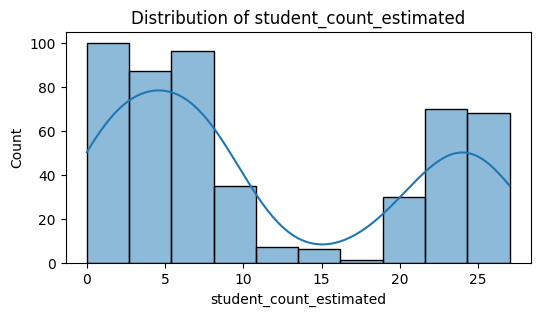

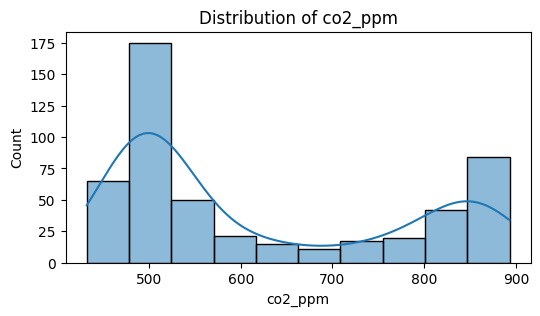

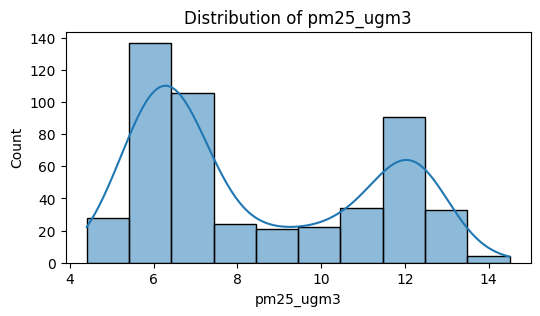

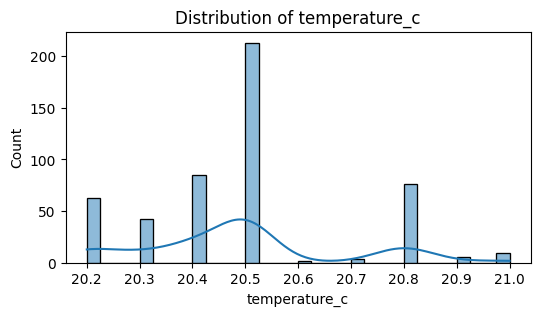

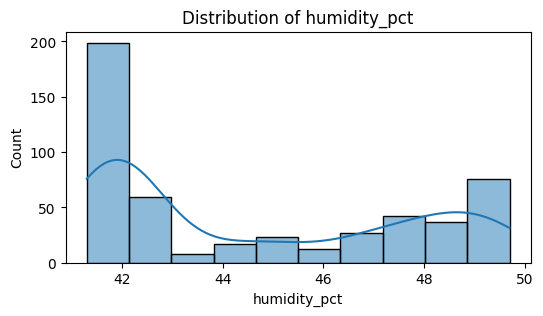

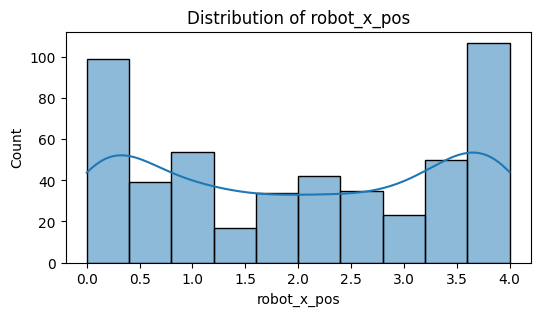

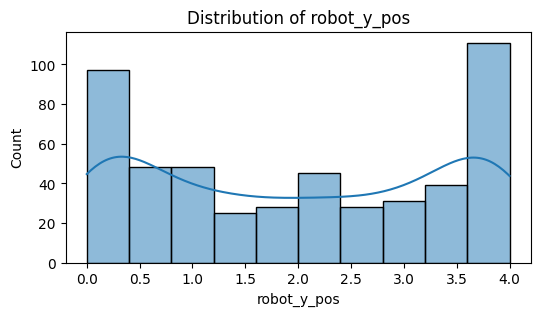

In [9]:
num_cols = df.select_dtypes(include=np.number).columns

for col in num_cols:
    plt.figure(figsize=(6,3))
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()

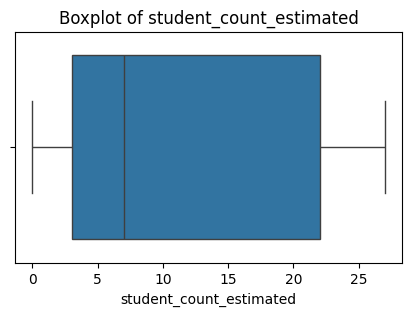

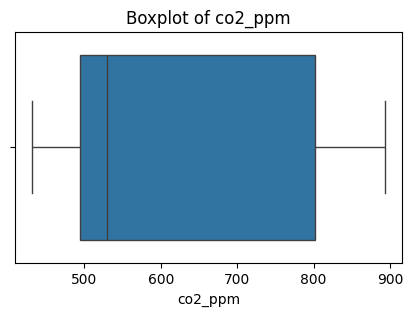

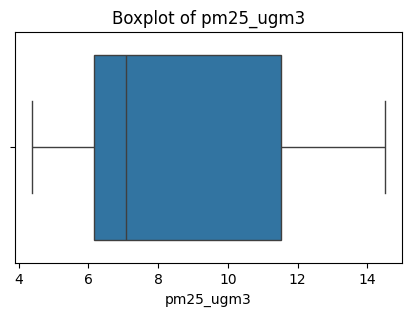

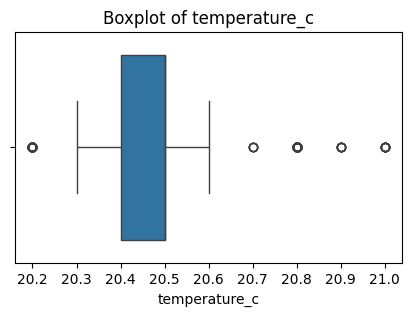

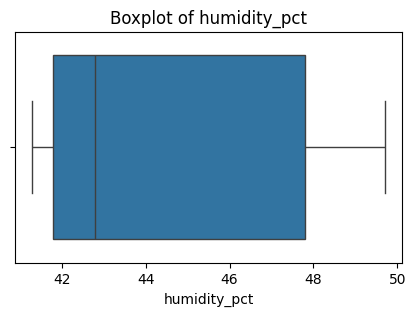

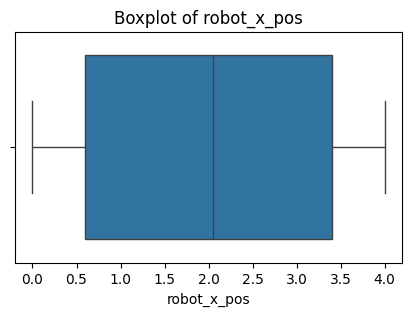

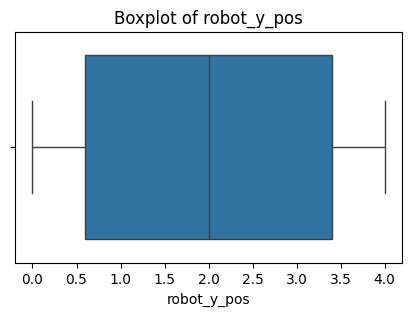

In [10]:
for col in num_cols:
    plt.figure(figsize=(5,3))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

C:\Users\ankit\AppData\Local\Temp\ipykernel_11312\3001378206.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include='object').columns


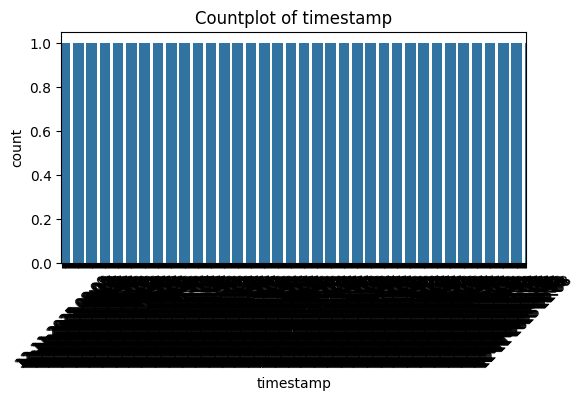

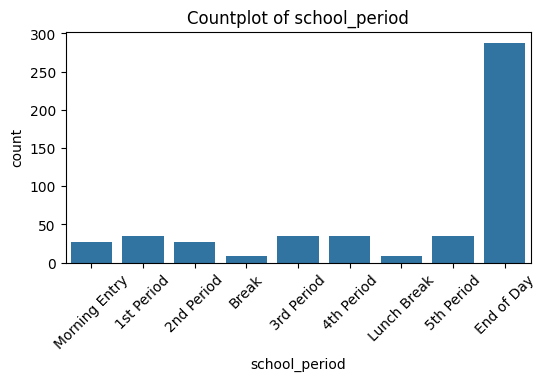

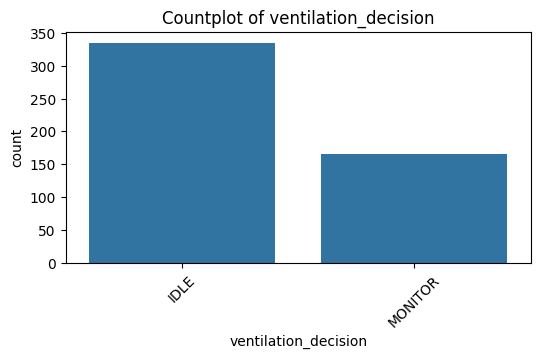

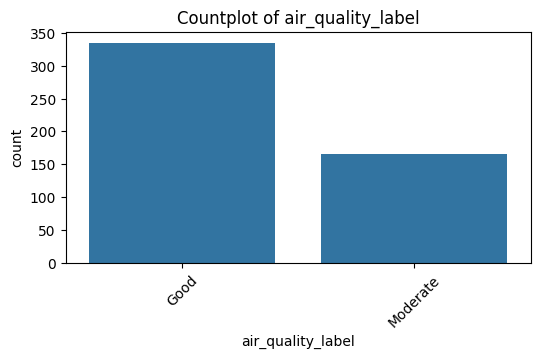

In [11]:
cat_cols = df.select_dtypes(include='object').columns

for col in cat_cols:
    plt.figure(figsize=(6,3))
    sns.countplot(x=df[col])
    plt.title(f"Countplot of {col}")
    plt.xticks(rotation=45)
    plt.show()

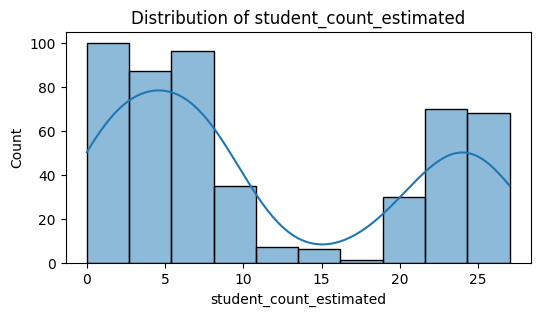

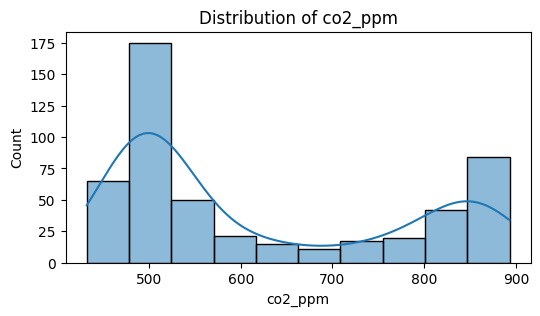

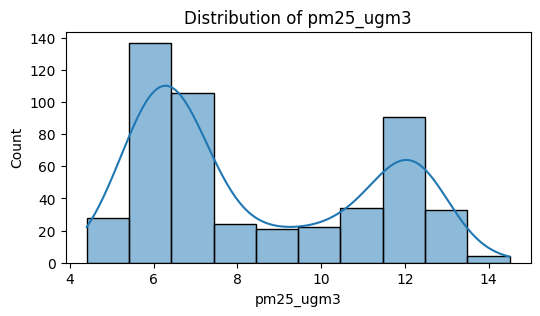

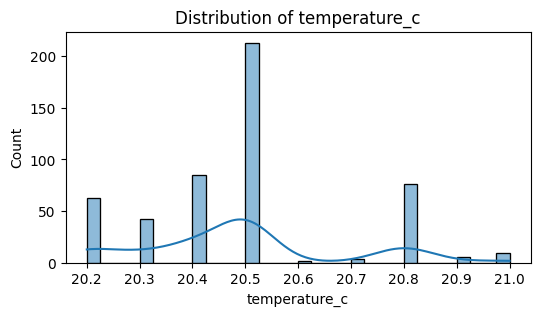

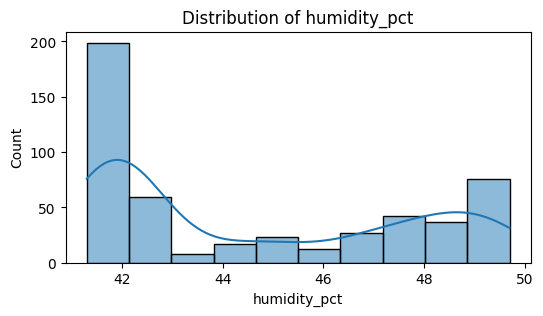

In [19]:
num_cols = [
    'student_count_estimated','co2_ppm','pm25_ugm3',
    'temperature_c','humidity_pct'
]

for col in num_cols:
    plt.figure(figsize=(6,3))
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()

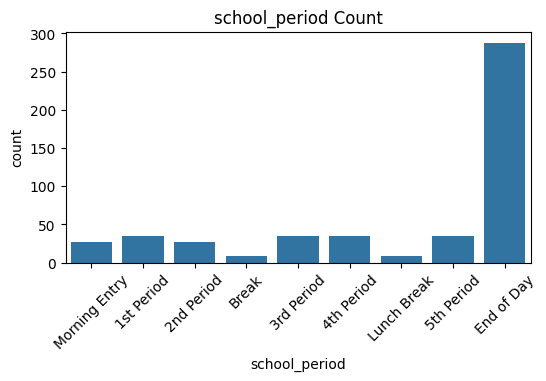

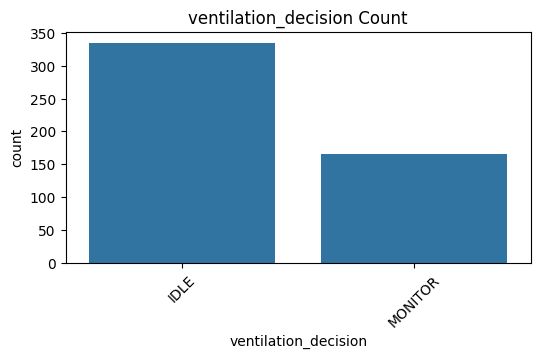

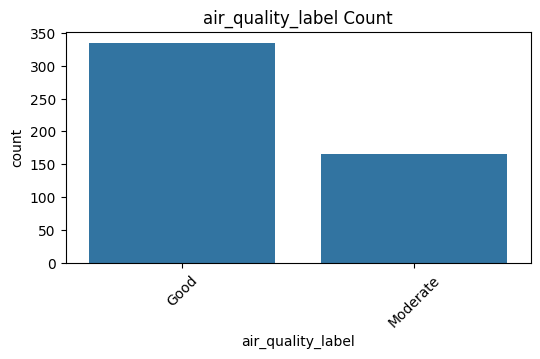

In [20]:
cat_cols = ['school_period','ventilation_decision','air_quality_label']

for col in cat_cols:
    plt.figure(figsize=(6,3))
    sns.countplot(x=df[col])
    plt.title(f"{col} Count")
    plt.xticks(rotation=45)
    plt.show()

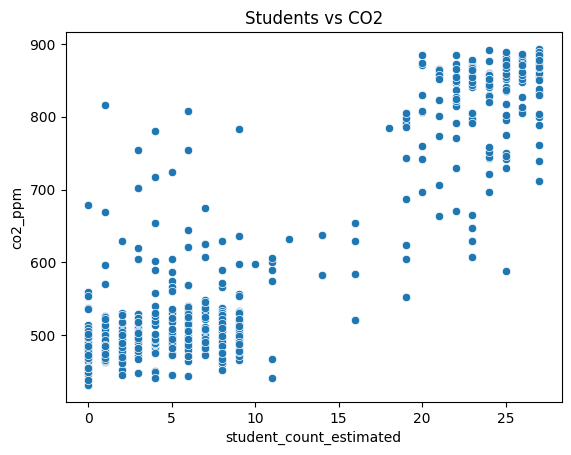

In [21]:
sns.scatterplot(x='student_count_estimated', y='co2_ppm', data=df)
plt.title("Students vs CO2")
plt.show()

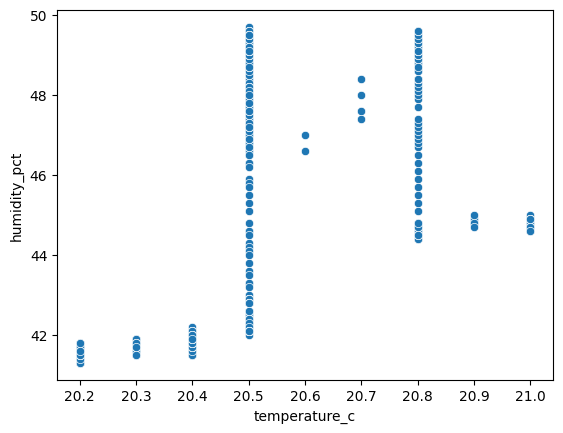

In [22]:
sns.scatterplot(x='temperature_c', y='humidity_pct', data=df)
plt.show()

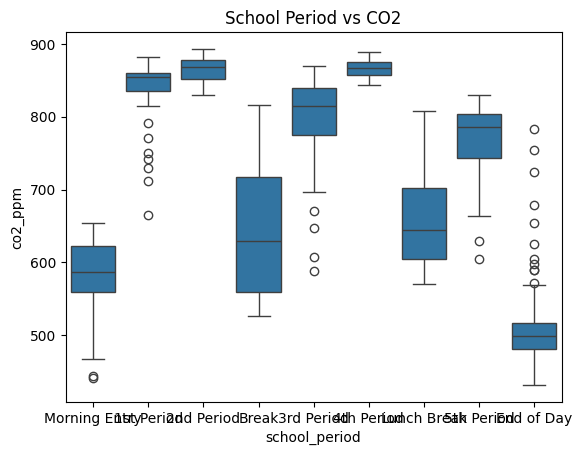

In [23]:
sns.boxplot(x='school_period', y='co2_ppm', data=df)
plt.title("School Period vs CO2")
plt.show()

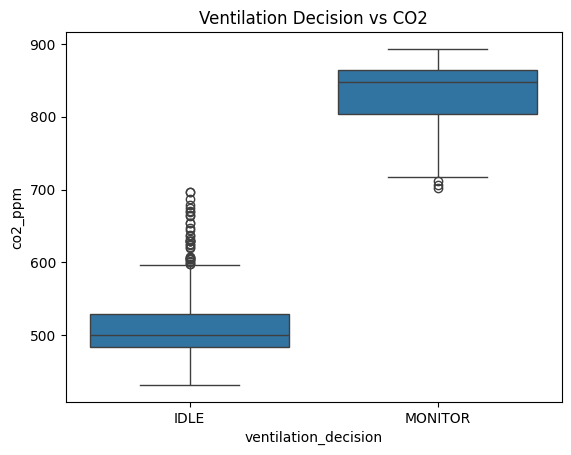

In [24]:
sns.boxplot(x='ventilation_decision', y='co2_ppm', data=df)
plt.title("Ventilation Decision vs CO2")
plt.show()

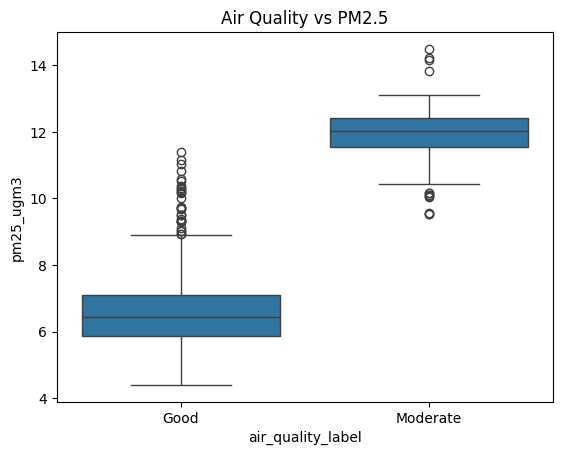

In [25]:
sns.boxplot(x='air_quality_label', y='pm25_ugm3', data=df)
plt.title("Air Quality vs PM2.5")
plt.show()

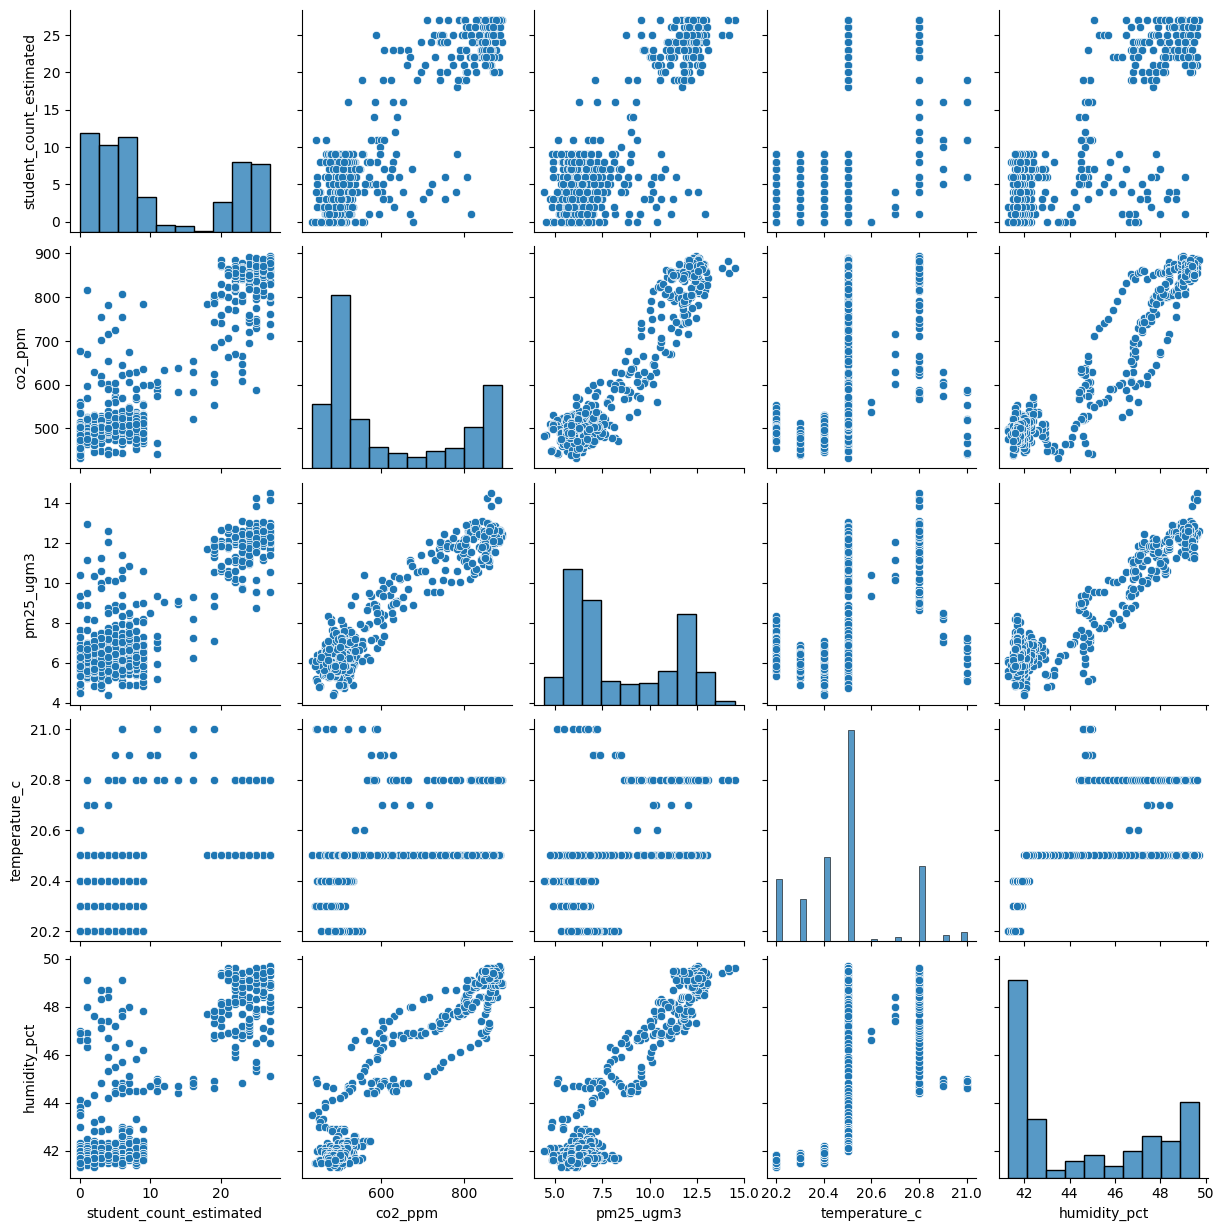

In [26]:
sns.pairplot(df[num_cols])
plt.show()

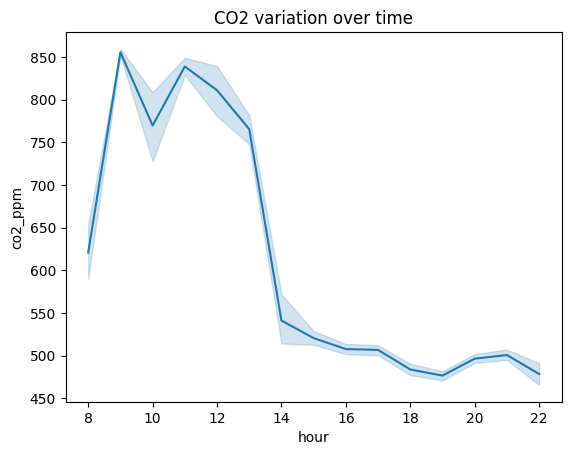

In [27]:
sns.lineplot(x='hour', y='co2_ppm', data=df)
plt.title("CO2 variation over time")
plt.show()